In [1]:
import os
import sys
from pathlib import Path

os.environ.setdefault("JAX_PLATFORM_NAME", "cpu")
os.environ.setdefault("JAX_ENABLE_X64", "True")

repo_python = Path.cwd() / "python"
if repo_python.exists() and str(repo_python) not in sys.path:
    sys.path.insert(0, str(repo_python))

import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import root

import jax.numpy as jnp

from docomo_bt_management.dsl import (
    D,
    DiscretizationRequest,
    discretization,
)


In [2]:
def f(x, y, t):
    return D(x, "t", order=2) + y + t


grid = jnp.linspace(0.0, 1.0, 5, dtype=jnp.float64)
halo = 2
halo_offsets = jnp.arange(grid.size + halo, dtype=grid.dtype) - halo // 2
shared_halo_points = grid[0] + halo_offsets * (grid[1] - grid[0])
f_tilde, restore_blocks = discretization(
    f,
    DiscretizationRequest(grid=grid, scheme="central"),
)

x_samples = shared_halo_points**2
y_samples = 10.0 + shared_halo_points
z = jnp.concatenate([x_samples, y_samples])
blocks = restore_blocks(z)

assert restore_blocks.names() == ("x", "y")
assert blocks["x"].shape == (7,)
assert blocks["y"].shape == (7,)

actual = f_tilde(z)
expected = 12.0 + 2.0 * grid
assert actual.shape == (5,)
assert bool(jnp.allclose(actual, expected, atol=1e-4))
actual


Array([12. , 12.5, 13. , 13.5, 14. ], dtype=float64)

In [3]:
def second_order_polynomial(x, t):
    return D(x, "t", order=2) + x


second_grid = jnp.linspace(0.0, 1.0, 5, dtype=jnp.float64)
second_tilde, _ = discretization(
    second_order_polynomial,
    DiscretizationRequest(grid=second_grid, scheme="central"),
)
second_halo_points = jnp.linspace(-0.25, 1.25, 7, dtype=jnp.float64)
second_actual = second_tilde(second_halo_points**2)
second_expected = 2.0 + second_grid**2
assert bool(jnp.allclose(second_actual, second_expected, atol=1e-4))


def fourth_order_polynomial(x, t):
    return D(x, "t", order=4) + x


fourth_tilde, _ = discretization(
    fourth_order_polynomial,
    DiscretizationRequest(grid=grid, scheme="central"),
)
fourth_halo_points = jnp.linspace(-0.5, 1.5, 9, dtype=jnp.float64)
fourth_actual = fourth_tilde(fourth_halo_points**4)
fourth_expected = 24.0 + grid**4
assert bool(jnp.allclose(fourth_actual, fourth_expected, atol=1e-3))
second_actual, fourth_actual

(Array([2.    , 2.0625, 2.25  , 2.5625, 3.    ], dtype=float64),
 Array([24.        , 24.00390625, 24.0625    , 24.31640625, 25.        ],      dtype=float64))

In [4]:
def nonlinear_residual(x, t):
    exact = 1.0 + t**2
    return D(x, "t", order=2) + x**2 - (2.0 + exact**2)


nonlinear_grid = jnp.linspace(0.0, 1.0, 6, dtype=jnp.float64)
halo_points = jnp.linspace(-0.2, 1.2, 8, dtype=jnp.float64)
exact_z = 1.0 + halo_points**2
nonlinear_tilde, nonlinear_blocks = discretization(
    nonlinear_residual,
    DiscretizationRequest(grid=nonlinear_grid, scheme="central"),
)


def nonlinear_system(z_values):
    z_array = jnp.asarray(z_values, dtype=jnp.float64)
    ode_residual = np.asarray(nonlinear_tilde(z_array), dtype=float)
    boundary_residual = np.asarray(
        jnp.array([z_array[0] - exact_z[0], z_array[-1] - exact_z[-1]]),
        dtype=float,
    )
    return np.concatenate([ode_residual, boundary_residual])


initial = np.asarray(
    exact_z + 0.05 * jnp.sin(jnp.arange(exact_z.size)),
    dtype=float,
)
solution = root(nonlinear_system, initial)
assert solution.success
assert np.linalg.norm(nonlinear_system(solution.x), ord=np.inf) < 5e-5

solved_block = nonlinear_blocks(jnp.asarray(solution.x, dtype=jnp.float64))["x"]
solved_grid_values = solved_block[1:-1]
exact_grid_values = 1.0 + nonlinear_grid**2
assert bool(jnp.allclose(solved_grid_values, exact_grid_values, atol=2e-3))
solution.success, np.linalg.norm(nonlinear_system(solution.x), ord=np.inf), solved_grid_values

(True,
 np.float64(2.7533531010703882e-14),
 Array([1.  , 1.04, 1.16, 1.36, 1.64, 2.  ], dtype=float64))

In [5]:
def expression_derivative_residual(x, t):
    return D(jnp.sin(x), "t") + x


def derivative_composition_residual(x, t):
    return jnp.sin(D(x, "t")) + x


expression_grid = jnp.linspace(0.0, 1.0, 5, dtype=jnp.float64)
expression_halo = 2
expression_offsets = (
    jnp.arange(expression_grid.size + expression_halo, dtype=expression_grid.dtype)
    - expression_halo // 2
)
expression_halo_points = (
    expression_grid[0]
    + expression_offsets * (expression_grid[1] - expression_grid[0])
)
expression_samples = 1.0 + expression_halo_points**2

expression_tilde, _ = discretization(
    expression_derivative_residual,
    DiscretizationRequest(grid=expression_grid, scheme="central"),
)
expression_actual = expression_tilde(expression_samples)
step = expression_grid[1] - expression_grid[0]
expression_expected_derivative = (
    jnp.sin(expression_samples[2:]) - jnp.sin(expression_samples[:-2])
) / (2.0 * step)
expression_expected = expression_expected_derivative + (1.0 + expression_grid**2)
assert bool(jnp.allclose(expression_actual, expression_expected, atol=1e-6))

composition_tilde, _ = discretization(
    derivative_composition_residual,
    DiscretizationRequest(grid=expression_grid, scheme="central"),
)
composition_samples = expression_halo_points**2
composition_actual = composition_tilde(composition_samples)
composition_expected = jnp.sin(2.0 * expression_grid) + expression_grid**2
assert bool(jnp.allclose(composition_actual, composition_expected, atol=1e-6))
expression_actual, composition_actual


(Array([1.        , 1.27752727, 1.5027813 , 1.48312561, 1.09459833],      dtype=float64),
 Array([0.        , 0.54192554, 1.09147098, 1.55999499, 1.90929743],      dtype=float64))

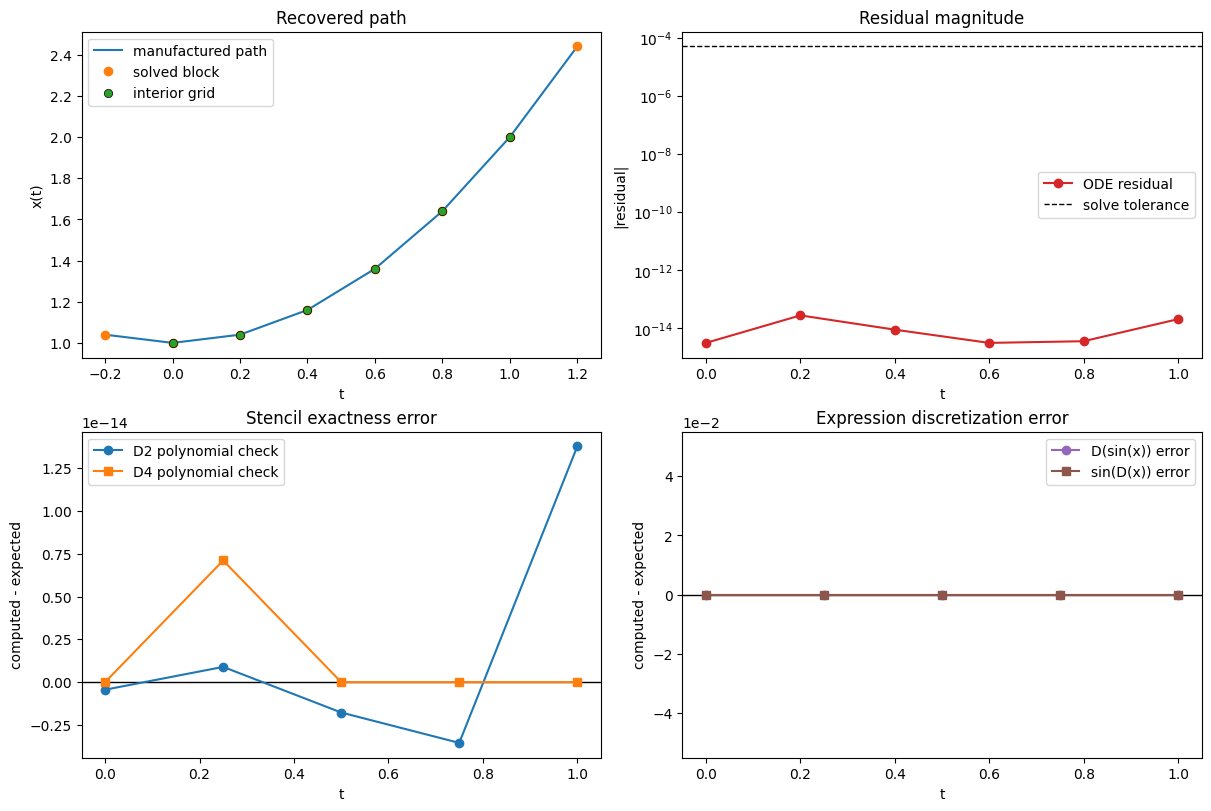

(np.float64(3.9968028886505635e-15),
 np.float64(2.7533531010703882e-14),
 np.float64(0.0),
 np.float64(1.3766765505351941e-14),
 np.float64(0.0))

In [6]:
polynomial_error_second = np.asarray(second_actual - second_expected, dtype=float)
polynomial_error_fourth = np.asarray(fourth_actual - fourth_expected, dtype=float)
expression_error = np.asarray(expression_actual - expression_expected, dtype=float)
composition_error = np.asarray(composition_actual - composition_expected, dtype=float)
solution_residual = nonlinear_system(solution.x)
ode_residual = solution_residual[:-2]
boundary_residual = solution_residual[-2:]

halo_points_np = np.asarray(halo_points, dtype=float)
nonlinear_grid_np = np.asarray(nonlinear_grid, dtype=float)
solution_np = np.asarray(solution.x, dtype=float)
exact_z_np = np.asarray(exact_z, dtype=float)
solved_grid_np = np.asarray(solved_grid_values, dtype=float)
exact_grid_np = np.asarray(exact_grid_values, dtype=float)
expression_grid_np = np.asarray(expression_grid, dtype=float)

fig, axes = plt.subplots(2, 2, figsize=(12, 8), constrained_layout=True)
axes = axes.ravel()

axes[0].plot(halo_points_np, exact_z_np, color="tab:blue", label="manufactured path")
axes[0].plot(halo_points_np, solution_np, "o", color="tab:orange", label="solved block")
axes[0].scatter(
    nonlinear_grid_np,
    solved_grid_np,
    color="tab:green",
    edgecolor="black",
    linewidth=0.5,
    zorder=3,
    label="interior grid",
)
axes[0].set_title("Recovered path")
axes[0].set_xlabel("t")
axes[0].set_ylabel("x(t)")
axes[0].legend()

axes[1].semilogy(
    nonlinear_grid_np,
    np.maximum(np.abs(ode_residual), 1e-16),
    "o-",
    color="tab:red",
    label="ODE residual",
)
axes[1].axhline(5e-5, color="black", linestyle="--", linewidth=1.0, label="solve tolerance")
axes[1].set_title("Residual magnitude")
axes[1].set_xlabel("t")
axes[1].set_ylabel("|residual|")
axes[1].legend()

axes[2].axhline(0.0, color="black", linewidth=1.0)
axes[2].plot(
    np.asarray(second_grid, dtype=float),
    polynomial_error_second,
    "o-",
    label="D2 polynomial check",
)
axes[2].plot(
    np.asarray(grid, dtype=float),
    polynomial_error_fourth,
    "s-",
    label="D4 polynomial check",
)
axes[2].set_title("Stencil exactness error")
axes[2].set_xlabel("t")
axes[2].set_ylabel("computed - expected")
axes[2].ticklabel_format(axis="y", style="sci", scilimits=(0, 0))
axes[2].legend()

axes[3].axhline(0.0, color="black", linewidth=1.0)
axes[3].plot(
    expression_grid_np,
    expression_error,
    "o-",
    color="tab:purple",
    label="D(sin(x)) error",
)
axes[3].plot(
    expression_grid_np,
    composition_error,
    "s-",
    color="tab:brown",
    label="sin(D(x)) error",
)
axes[3].set_title("Expression discretization error")
axes[3].set_xlabel("t")
axes[3].set_ylabel("computed - expected")
axes[3].ticklabel_format(axis="y", style="sci", scilimits=(0, 0))
axes[3].legend()

plt.show()

max_path_error = np.linalg.norm(solved_grid_np - exact_grid_np, ord=np.inf)
max_ode_residual = np.linalg.norm(ode_residual, ord=np.inf)
max_boundary_residual = np.linalg.norm(boundary_residual, ord=np.inf)
max_polynomial_error = max(
    np.linalg.norm(polynomial_error_second, ord=np.inf),
    np.linalg.norm(polynomial_error_fourth, ord=np.inf),
)
max_expression_error = max(
    np.linalg.norm(expression_error, ord=np.inf),
    np.linalg.norm(composition_error, ord=np.inf),
)
assert max_path_error < 2e-3
assert max_ode_residual < 5e-5
assert max_boundary_residual < 5e-5
assert max_polynomial_error < 1e-3
assert max_expression_error < 1e-6
max_path_error, max_ode_residual, max_boundary_residual, max_polynomial_error, max_expression_error


In [7]:
def path(t):
    return t**3


d2_path = D(path, "t", order=2)
assert bool(jnp.allclose(d2_path(2.0), 12.0))

In [8]:
for bad_z in (z[:-1], jnp.concatenate([z, jnp.array([0.0], dtype=z.dtype)])):
    try:
        f_tilde(bad_z)
    except TypeError:
        pass
    else:
        raise AssertionError("bad z length did not fail")


for bad_function in (lambda x: x, lambda x, t, y: x + y + t):
    try:
        discretization(bad_function, DiscretizationRequest(grid=grid))
    except ValueError:
        pass
    else:
        raise AssertionError("bad t signature did not fail")